In [2]:
import xarray as xr 
import numpy as np
import json
from datetime import date, timedelta
import os

In [16]:
valid

array([False, False, False,  True,  True,  True,  True, False, False,
        True,  True,  True,  True,  True,  True,  True, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

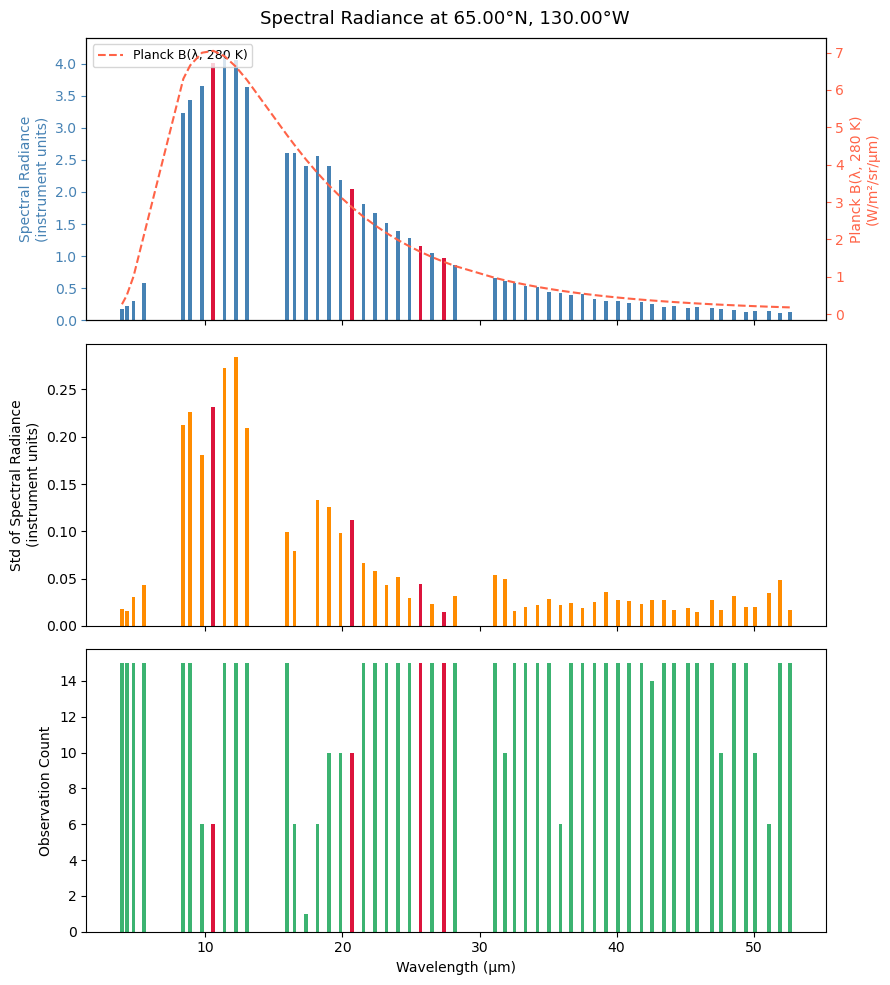

In [17]:
import matplotlib.pyplot as plt

ds_binned_all = xr.open_dataset('2512RAD.nc')

# ── select nearest grid point to 65°N, 130°W ─────────────────────────────────
point = ds_binned_all.sel(lat=65.0, lon=-130.0, method='nearest')

wl  = point['wavelength'].values
rad = point['spectral_radiance'].values
std = point['spectral_radiance_std'].values
cnt = point['spectral_radiance_count'].values

# drop spectral channels with no wavelength label
valid        = np.isfinite(wl)
valid_indices = np.where(valid)[0]          # original channel numbers that survived
wl_v, rad_v, std_v, cnt_v = wl[valid], rad[valid], std[valid], cnt[valid]

# map original spectral index → position in wl_v (some channels were removed above)
orig_to_filt = {orig: i for i, orig in enumerate(valid_indices)}

# ── Planck function (W/m²/sr/μm) at a reference Earth temperature ────────────
H, C, KB = 6.626e-34, 2.998e8, 1.381e-23
T_REF = 280   # K

def planck_um(lam_um, T):
    """Spectral radiance in W/m²/sr/μm for wavelength in μm."""
    lam = lam_um * 1e-6
    return (2 * H * C**2 / lam**5) / (np.expm1(H * C / (lam * KB * T))) * 1e-6

planck_v = planck_um(wl_v, T_REF)

# ── bar colors: highlight original channels 12, 24, 30, 32 ───────────────────
HIGHLIGHT_IDX  = [12, 24, 30, 32]           # original spectral channel indices
HIGHLIGHT_FILT = [orig_to_filt[ch] for ch in HIGHLIGHT_IDX if ch in orig_to_filt]
HIGHLIGHT_COLOR = 'crimson'

def make_colors(n, highlight_filt, default_color):
    colors = [default_color] * n
    for i in highlight_filt:
        colors[i] = HIGHLIGHT_COLOR
    return colors

bar_w = np.diff(wl_v).min() * 0.8

colors_rad = make_colors(len(wl_v), HIGHLIGHT_FILT, 'steelblue')
colors_std = make_colors(len(wl_v), HIGHLIGHT_FILT, 'darkorange')
colors_cnt = make_colors(len(wl_v), HIGHLIGHT_FILT, 'mediumseagreen')

# ── figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
fig.suptitle(
    f'Spectral Radiance at '
    f'{point.lat.item():.2f}°N, {abs(point.lon.item()):.2f}°W',
    fontsize=13
)

# --- subplot 1: measured radiance + Planck curve (twin axis) -----------------
ax1 = axes[0]
ax1.bar(wl_v, rad_v, width=bar_w, color=colors_rad, label='Measured radiance')
ax1.set_ylabel('Spectral Radiance\n(instrument units)', color='steelblue')
ax1.tick_params(axis='y', colors='steelblue')

ax1b = ax1.twinx()
ax1b.plot(wl_v, planck_v, color='tomato', linestyle='--',
          label=f'Planck B(λ, {T_REF} K)')
ax1b.set_ylabel(f'Planck B(λ, {T_REF} K)\n(W/m²/sr/μm)', color='tomato')
ax1b.tick_params(axis='y', colors='tomato')

lines  = ax1.get_lines() + ax1b.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=9)

# --- subplot 2: standard deviation -------------------------------------------
axes[1].bar(wl_v, std_v, width=bar_w, color=colors_std)
axes[1].set_ylabel('Std of Spectral Radiance\n(instrument units)')

# --- subplot 3: observation count --------------------------------------------
axes[2].bar(wl_v, cnt_v, width=bar_w, color=colors_cnt, align='center')
axes[2].set_ylabel('Observation Count')
axes[2].set_xlabel('Wavelength (μm)')

plt.tight_layout()
plt.show()

In [18]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# per-bar colors using the filtered positions (accounts for removed NaN channels)
hl = set(HIGHLIGHT_FILT)
c_rad = ['crimson' if i in hl else 'steelblue'      for i in range(len(wl_v))]
c_std = ['crimson' if i in hl else 'darkorange'     for i in range(len(wl_v))]
c_cnt = ['crimson' if i in hl else 'mediumseagreen' for i in range(len(wl_v))]

# customdata per bar: [original_channel_index, wavelength]
hover_data = np.stack([valid_indices.astype(float), wl_v], axis=1)

fig = make_subplots(
    rows=3, cols=1,
    specs=[[{'secondary_y': True}], [{'secondary_y': False}], [{'secondary_y': False}]],
    shared_xaxes=True,
    subplot_titles=('Spectral Radiance', 'Std of Spectral Radiance', 'Observation Count'),
    vertical_spacing=0.07,
)

# ── row 1: radiance bars + full Planck line ───────────────────────────────────
fig.add_trace(go.Bar(
    x=wl_v, y=rad_v,
    marker_color=c_rad,
    name='Measured radiance',
    customdata=hover_data,
    hovertemplate=(
        '<b>Channel %{customdata[0]:.0f}</b><br>'
        'Wavelength: %{customdata[1]:.4f} μm<br>'
        'Radiance: %{y:.4e}<extra></extra>'
    ),
), row=1, col=1, secondary_y=False)

fig.add_trace(go.Scatter(
    x=wl_v, y=planck_v,
    mode='lines',
    line=dict(color='tomato', dash='dash', width=1.5),
    name=f'Planck B(λ, {T_REF} K)',
    hovertemplate='Wavelength: %{x:.4f} μm<br>Planck: %{y:.4e} W/m²/sr/μm<extra></extra>',
), row=1, col=1, secondary_y=True)

# ── row 2: std bars ───────────────────────────────────────────────────────────
fig.add_trace(go.Bar(
    x=wl_v, y=std_v,
    marker_color=c_std,
    name='Std',
    showlegend=False,
    customdata=hover_data,
    hovertemplate=(
        '<b>Channel %{customdata[0]:.0f}</b><br>'
        'Wavelength: %{customdata[1]:.4f} μm<br>'
        'Std: %{y:.4e}<extra></extra>'
    ),
), row=2, col=1)

# ── row 3: count bars ─────────────────────────────────────────────────────────
fig.add_trace(go.Bar(
    x=wl_v, y=cnt_v,
    marker_color=c_cnt,
    name='Count',
    showlegend=False,
    customdata=hover_data,
    hovertemplate=(
        '<b>Channel %{customdata[0]:.0f}</b><br>'
        'Wavelength: %{customdata[1]:.4f} μm<br>'
        'Count: %{y:d}<extra></extra>'
    ),
), row=3, col=1)

# ── axes ──────────────────────────────────────────────────────────────────────
fig.update_yaxes(title_text='Spectral Radiance (inst. units)', row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text=f'Planck B(λ,{T_REF}K) (W/m²/sr/μm)',
                 title_font_color='tomato', tickfont_color='tomato',
                 row=1, col=1, secondary_y=True)
fig.update_yaxes(title_text='Std of Spectral Radiance', row=2, col=1)
fig.update_yaxes(title_text='Observation Count',        row=3, col=1)
fig.update_xaxes(title_text='Wavelength (μm)',          row=3, col=1)

fig.update_layout(
    title=f'Spectral Radiance at {point.lat.item():.2f}°N, {abs(point.lon.item()):.2f}°W',
    height=950,
    bargap=0.15,
    legend=dict(orientation='h', y=1.02, x=0),
)

fig.show()

In [11]:

ds_binned_all.wavelength

<xarray.DataArray 'wavelength' (spectral: 63)> Size: 252B
array([      nan,       nan,       nan,  3.921875,  4.265625,  4.765625,
        5.507812,       nan,       nan,  8.398438,  8.898438,  9.757812,
       10.585938, 11.40625 , 12.226562, 13.039062,       nan,       nan,
       15.960938, 16.507812, 17.328125, 18.179688, 19.023438, 19.859375,
       20.710938, 21.539062, 22.390625, 23.21875 , 24.054688, 24.890625,
       25.703125, 26.539062, 27.40625 , 28.226562,       nan,       nan,
       31.15625 , 31.835938, 32.554688, 33.351562, 34.234375, 35.09375 ,
       35.90625 , 36.6875  , 37.507812, 38.390625, 39.25    , 40.125   ,
       40.929688, 41.8125  , 42.554688, 43.46875 , 44.1875  , 45.195312,
       45.875   , 46.9375  , 47.609375, 48.570312, 49.429688, 50.09375 ,
       51.125   , 51.898438, 52.65625 ], dtype=float32)
Coordinates:
  * spectral  (spectral) int64 504B 0 1 2 3 4 5 6 7 ... 55 56 57 58 59 60 61 62
Attributes:
    units:    nm